# SpaceTime for Causal Discovery from Non-stationary Time Series



In [4]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd

from causalchange.causal_change import CausalChange
from causalchange.config.cc_config import ChangepointMode, ChangepointScope
from causalchange.config.cc_types import (
    ContextMode,
    DataMode,
    GPType,
    GraphSearch,
    ScoreType,
)
from causalchange.plotting import plot_changepoints, plot_temporal_graph

## 1. Synthetic Data Generation


Data generation as

- `x0(t-1) -> x0(t)`, `x1(t-1) -> x1(t)`, `x2(t-1) -> x2(t)`

- `x0(t-1) -> x1(t)`, `x1(t-1) -> x2(t)`


- after the changepoint, the coefficient from `x0[t-1]` to `x1[t]` changes.

In [5]:
def simulate_spacetime_contexts(
    n: int = 160,
    changepoint: int = 80,
    contexts: tuple[str, ...] = ("A", "B"),
    seed: int = 42,
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    frames = []

    for context in contexts:
        x0 = np.zeros(n)
        x1 = np.zeros(n)
        x2 = np.zeros(n)

        for t in range(1, n):
            x0[t] = 0.6 * x0[t - 1] + rng.normal(scale=0.35)

            if t < changepoint:
                x1[t] = 0.5 * x1[t - 1] + 1.1 * x0[t - 1] + rng.normal(scale=0.25)
            else:
                x1[t] = 0.5 * x1[t - 1] + 0.2 * x0[t - 1] + rng.normal(scale=0.90)

            x2[t] = 0.5 * x2[t - 1] + 0.8 * x1[t - 1] + rng.normal(scale=0.35)

        frames.append(
            pd.DataFrame(
                {
                    "context": context,
                    "x0": x0,
                    "x1": x1,
                    "x2": x2,
                }
            )
        )

    return pd.concat(frames, axis=0, ignore_index=True)

In [6]:
true_changepoint = 80

X = simulate_spacetime_contexts(
    n=160,
    changepoint=true_changepoint,
    contexts=("A", "B"),
    seed=42,
)

X.head()

,context,x0,x1,x2
0,A,0.000000,0.000000,0.000000
1,A,0.106651,-0.259996,0.262658
2,A,0.393188,-0.500441,-0.532431
3,A,0.280657,0.103226,-0.672448
4,A,-0.130171,0.580185,0.018584




Plots

array([<Axes: ylabel='x0'>, <Axes: ylabel='x1'>,
       <Axes: xlabel='time', ylabel='x2'>], dtype=object)

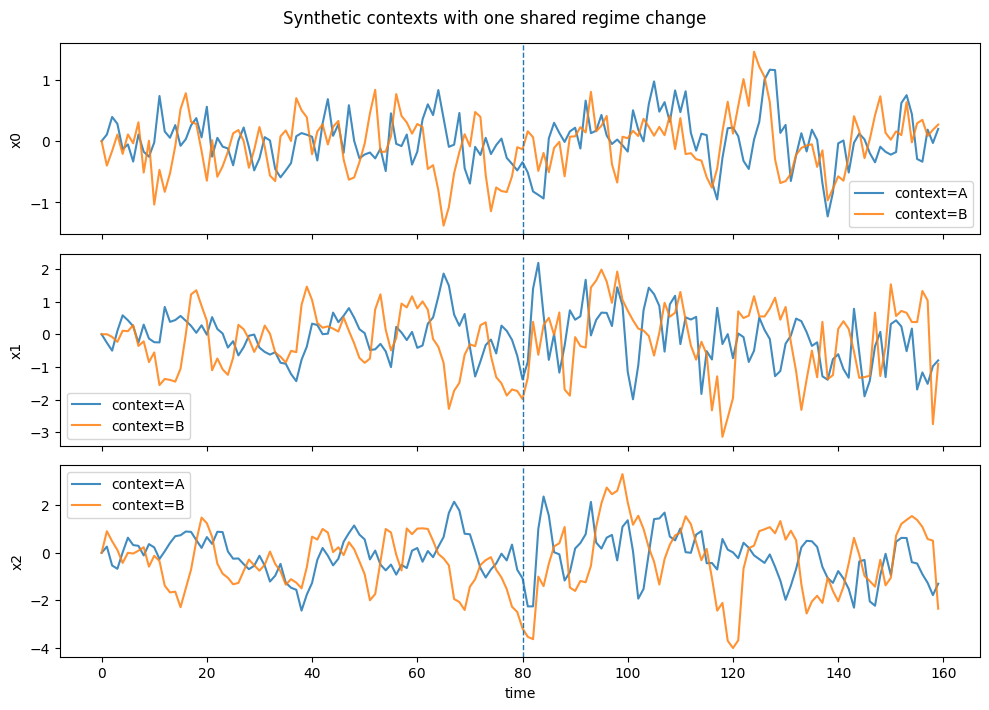

In [7]:
plot_changepoints(
    X,
    changepoints=[true_changepoint],
    context_col="context",
    title="Synthetic contexts with one shared regime change",
)

## 2. SpaceTime with known changepoints

`ChangepointMode.FIXED` tells SpaceTime where the regime boundaries are.  
This is useful when changepoints are known from domain knowledge or an external detector.

In [8]:
cc_fixed = CausalChange(
    data_mode=DataMode.TIME_CONTEXTS,
    graph_search=GraphSearch.GLOBE,
    score_type=ScoreType.LIN,
    context_mode=ContextMode.SKIP,
    context_col="context",
    tau_max=2,
    detect_contexts=True,
    detect_regimes=True,
    changepoint_mode=ChangepointMode.FIXED,
    fixed_changepoints=[true_changepoint],
)

cc_fixed.fit(X)

instantaneous_edges = [edge for edge in cc_fixed.graph_.edges if edge[0][1] == 0 and edge[1][1] == 0]

lagged_edges = [edge for edge in cc_fixed.graph_.edges if edge[0][1] > 0 and edge[1][1] == 0]

print("Fixed changepoints:", cc_fixed.changepoints_)

print("\nInstantaneous edges:")
for edge in instantaneous_edges:
    print("  ", edge)

print("\nLagged edges:")
for edge in lagged_edges:
    print("  ", edge)

print("\nEdge strengths:")
pd.Series(cc_fixed.result_.edge_strengths, name="strength").sort_values(ascending=False)

Fixed changepoints: [80]

Instantaneous edges:

Lagged edges:
   (('x0', 1), ('x1', 0))
   (('x0', 1), ('x0', 0))
   (('x1', 1), ('x2', 0))
   (('x1', 1), ('x1', 0))
   (('x2', 1), ('x2', 0))

Edge strengths:


(x1, 1)  (x2, 0)    350.201687
(x2, 1)  (x2, 0)    249.080310
(x1, 1)  (x1, 0)    148.640232
(x0, 1)  (x1, 0)    144.411414
         (x0, 0)     98.408815
Name: strength, dtype: float64

<Axes: title={'center': 'Estimated temporal graph'}>

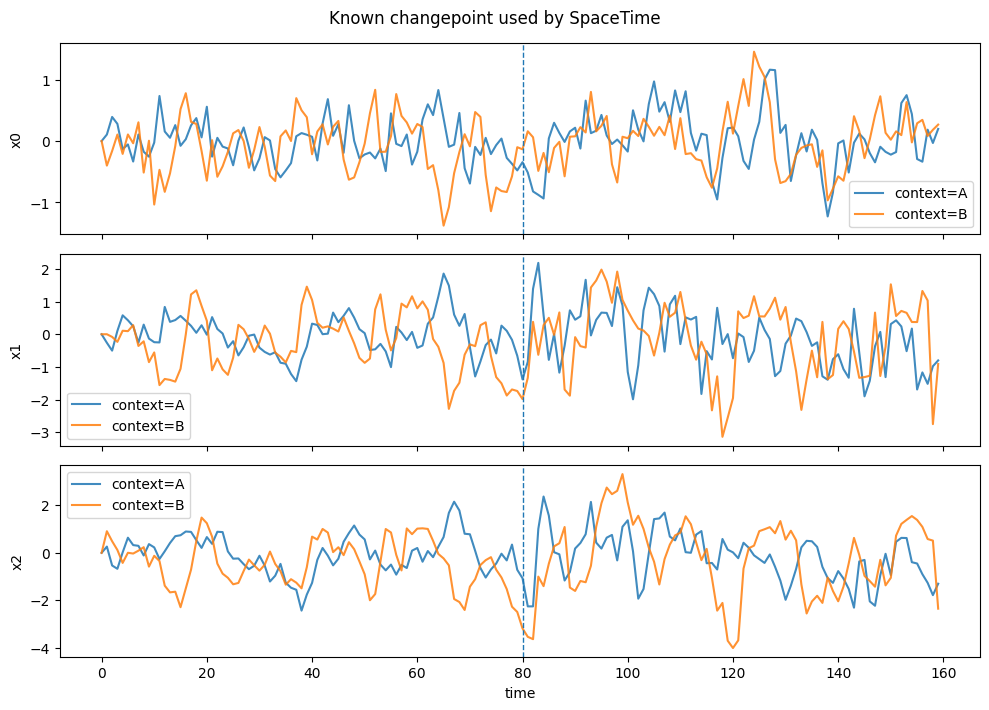

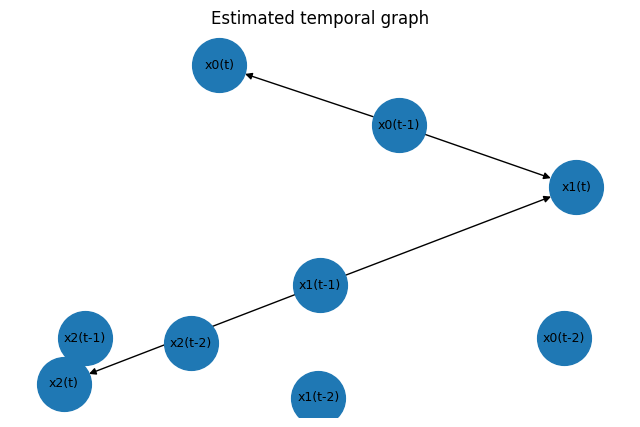

In [10]:
plot_changepoints(
    X,
    changepoints=cc_fixed.changepoints_,
    context_col="context",
    title="Known changepoint used by SpaceTime",
)

plot_temporal_graph(
    cc_fixed.graph_,
    title="Estimated temporal graph",
)

In [11]:
def edge_recovery_summary(estimated_edges, true_edges):
    estimated_edges = set(estimated_edges)
    true_edges = set(true_edges)

    tp = estimated_edges & true_edges
    fp = estimated_edges - true_edges
    fn = true_edges - estimated_edges

    precision = len(tp) / max(len(tp) + len(fp), 1)
    recall = len(tp) / max(len(tp) + len(fn), 1)

    return {
        "precision": precision,
        "recall": recall,
        "true_positives": sorted(tp),
        "false_positives": sorted(fp),
        "false_negatives": sorted(fn),
    }


lagged_edges = {edge for edge in cc_fixed.graph_.edges if edge[0][1] > 0 and edge[1][1] == 0}
expected_graph = {
    (("x0", 1), ("x0", 0)),
    (("x1", 1), ("x1", 0)),
    (("x2", 1), ("x2", 0)),
    (("x0", 1), ("x1", 0)),
    (("x1", 1), ("x2", 0)),
}


def changepoint_error(detected, true_changepoint):
    if not detected:
        return None
    return min(abs(cp - true_changepoint) for cp in detected)


expected_contexts = {
    "x0": {"A": 0, "B": 0},
    "x1": {"A": 0, "B": 0},
    "x2": {"A": 0, "B": 0},
}

expected_regimes = {
    "x0": {0: 0, 1: 0},  # stationary mechanism
    "x1": {0: 0, 1: 1},  # direct mechanism change
}

In [12]:
print("Context partitions:")
print(cc_fixed.result_.grid_clusters.contexts)

print("\nRegime partitions:")
print(cc_fixed.result_.grid_clusters.regimes)
pd.DataFrame(cc_fixed.result_.grid_clusters.diagnostics["tests"])
# print("\nPartition diagnostics:")
# print(cc_fixed.result_.partitions.diagnostics)

Context partitions:
{'x0': {'B': 0, 'A': 0}, 'x1': {'B': 0, 'A': 0}, 'x2': {'B': 0, 'A': 0}}

Regime partitions:
{'x0': {0: 0, 1: 0}, 'x1': {0: 0, 1: 1}, 'x2': {0: 0, 1: 0}}


,kind,target,regime_a,regime_b,pvalue,same,method,context_a,context_b,regime
0,regime,x0,0.0,1.0,0.735183,True,kci,NaN,NaN,NaN
1,regime,x1,0.0,1.0,0.000008,False,kci,NaN,NaN,NaN
2,regime,x2,0.0,1.0,0.122807,True,kci,NaN,NaN,NaN
3,context,x0,NaN,NaN,0.176536,True,kci,A,B,0.0
4,context,x0,NaN,NaN,0.931504,True,kci,A,B,1.0
5,context,x1,NaN,NaN,0.749188,True,kci,A,B,0.0
6,context,x1,NaN,NaN,0.471097,True,kci,A,B,1.0
7,context,x2,NaN,NaN,0.446066,True,kci,A,B,0.0
8,context,x2,NaN,NaN,0.271130,True,kci,A,B,1.0


In [13]:
print("Lagged-edge recovery:")
edge_recovery_summary(lagged_edges, expected_graph)

Lagged-edge recovery:


{'precision': 1.0,
 'recall': 1.0,
 'true_positives': [(('x0', 1), ('x0', 0)),
  (('x0', 1), ('x1', 0)),
  (('x1', 1), ('x1', 0)),
  (('x1', 1), ('x2', 0)),
  (('x2', 1), ('x2', 0))],
 'false_positives': [],
 'false_negatives': []}

## 3. SpaceTime with changepoint detection

Use `ChangepointMode.DETECT` for changepoint detection in time.
For multiple contexts, the detector combines residuals across contexts.

In [14]:
cc_detect = CausalChange(
    data_mode=DataMode.TIME_CONTEXTS,
    graph_search=GraphSearch.GLOBE,
    score_type=ScoreType.LIN,
    context_mode=ContextMode.SKIP,
    context_col="context",
    tau_max=2,
    changepoint_mode=ChangepointMode.DETECT,
    d_min=20,
    max_iter=3,
    pelt_penalty="auto",
)

cc_detect.fit(X)

print("Detected changepoints:", cc_detect.changepoints_)
print("Closest changepoint error:", changepoint_error(cc_detect.changepoints_, true_changepoint))

print("\nEdges:")
for edge in sorted(cc_detect.graph_.edges()):
    print("  ", edge)

print("\nChangepoint diagnostics:")
cc_detect.result_.changepoint_diagnostics

Detected changepoints: [79]
Closest changepoint error: 1

Edges:
   (('x0', 1), ('x0', 0))
   (('x0', 1), ('x1', 0))
   (('x1', 1), ('x1', 0))
   (('x1', 1), ('x2', 0))
   (('x2', 1), ('x2', 0))

Changepoint diagnostics:


{'mode': 'detect',
 'scope': 'global',
 'changepoints': [79],
 'global': {'signal_shape': (158, 6),
  'selected_penalty': 1.3981958366851424,
  'design_changepoints': [77],
  'raw_changepoints': [79],
  'raw_offset': 2}}

<Axes: title={'center': 'Estimated temporal graph with detected changepoints'}>

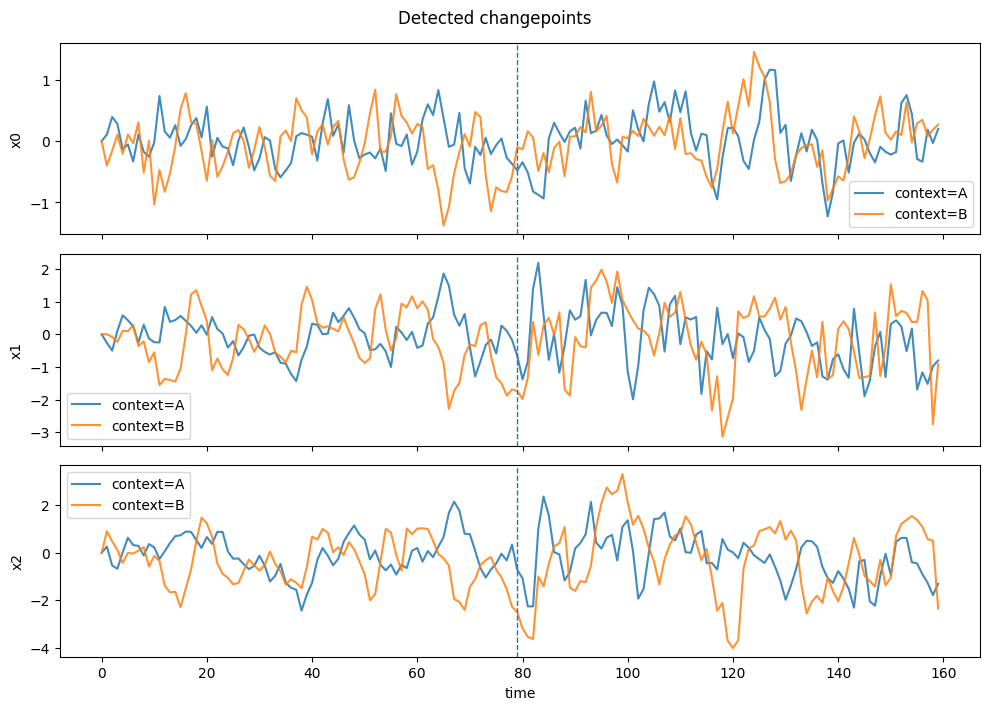

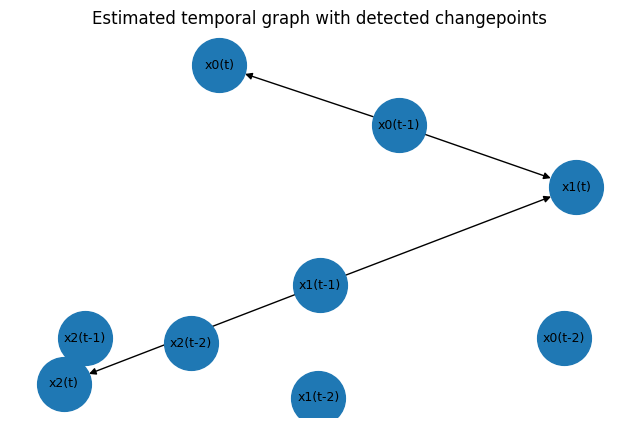

In [15]:
plot_changepoints(
    X,
    changepoints=cc_detect.changepoints_,
    context_col="context",
    title="Detected changepoints",
)

plot_temporal_graph(
    cc_detect.graph_,
    title="Estimated temporal graph with detected changepoints",
)

In [16]:
summary = pd.DataFrame(
    [
        {
            "run": "fixed",
            "changepoints": cc_fixed.changepoints_,
            "closest_cp_error": changepoint_error(cc_fixed.changepoints_, true_changepoint),
            "n_edges": cc_fixed.graph_.number_of_edges(),
        },
        {
            "run": "detected",
            "changepoints": cc_detect.changepoints_,
            "closest_cp_error": changepoint_error(cc_detect.changepoints_, true_changepoint),
            "n_edges": cc_detect.graph_.number_of_edges(),
        },
    ]
)

summary

,run,changepoints,closest_cp_error,n_edges
0,fixed,[80],0,5
1,detected,[79],1,5


## 4. Parameters

**Partitioning** Set `detect_contexts` and `detect_regimes` to `True` if you want SpaceTime to detect contexts and regimes
 with similar causal mechanisms using kernel testing, `False` to skip this as this can be expensive.


In [17]:
cc_detect = cc_fixed
cc_dontdetect = CausalChange(
    data_mode=DataMode.TIME_CONTEXTS,
    graph_search=GraphSearch.GLOBE,
    score_type=ScoreType.LIN,
    context_mode=ContextMode.SKIP,
    context_col="context",
    tau_max=2,
    detect_contexts=False,
    detect_regimes=False,
    changepoint_mode=ChangepointMode.FIXED,
    fixed_changepoints=[true_changepoint],
)

cc_dontdetect.fit(X)

print("\nNumber of mechanism tests:")
print(
    "detection off:",
    len(cc_dontdetect.result_.grid_clusters.diagnostics.get("tests", [])),
    "detection on:",
    len(cc_detect.result_.grid_clusters.diagnostics.get("tests", [])),
)

print("Context clusters:")
print(cc_detect.result_.grid_clusters.contexts)

print("\nRegime clusters:")
print(cc_detect.result_.grid_clusters.regimes)


Number of mechanism tests:
detection off: 0 detection on: 9
Context clusters:
{'x0': {'B': 0, 'A': 0}, 'x1': {'B': 0, 'A': 0}, 'x2': {'B': 0, 'A': 0}}

Regime clusters:
{'x0': {0: 0, 1: 0}, 'x1': {0: 0, 1: 1}, 'x2': {0: 0, 1: 0}}



**Scoring** The fast examples above use `ScoreType.LIN`. For nonlinear MDL scoring use

- `score_type=GPType.EXACT` for exact GP-MDL,
- `score_type=GPType.FOURIER` for a random Fourier feature approximation.

(These are slower, so this cell uses fewer restarts and disables refinement)

In [18]:
cc_rff = CausalChange(
    data_mode=DataMode.TIME_CONTEXTS,
    graph_search=GraphSearch.GLOBE,
    score_type=GPType.FOURIER,
    context_mode=ContextMode.SKIP,
    context_col="context",
    tau_max=2,
    changepoint_mode=ChangepointMode.FIXED,
    fixed_changepoints=[true_changepoint],
    score_kwargs={
        "D": 64,
        "restarts": 2,
        "refine": False,
        "seed": 42,
    },
)

cc_rff.fit(X)

print("RFF edges:")
for edge in sorted(cc_rff.graph_.edges()):
    print("  ", edge)

RFF edges:
   (('x0', 1), ('x0', 0))
   (('x0', 1), ('x1', 0))
   (('x1', 1), ('x1', 0))
   (('x1', 1), ('x2', 0))
   (('x2', 1), ('x2', 0))



**Changepoint Scope** By default we detect changepoints across all contexts, but you can use changepoint_scope to control this,

- `changepoint_scope=ChangepointScope.GLOBAL` global changepoints as in the paper,
- `changepoint_scope=ChangepointScope.PER_CONTEXT` changepoints per context.

For simplicity, the partitioning step will use the union of all changepoints across contexts in the latter case.


Changepoints used downstream:
[43, 80]

Changepoints by context:
  A: [43]
  B: [80]


{'mode': 'detect',
 'scope': 'per-context',
 'changepoints': [43, 80],
 'by_context': {'A': [43], 'B': [80]},
 'context_diagnostics': {'A': {'signal_shape': (158, 3),
   'selected_penalty': 1.7880184838248605,
   'design_changepoints': [41],
   'raw_changepoints': [43],
   'raw_offset': 2},
  'B': {'signal_shape': (158, 3),
   'selected_penalty': 1.7880184838248605,
   'design_changepoints': [78],
   'raw_changepoints': [80],
   'raw_offset': 2}},
 'note': 'Per-context changepoints are detected separately and their union is used as the downstream regime grid.'}

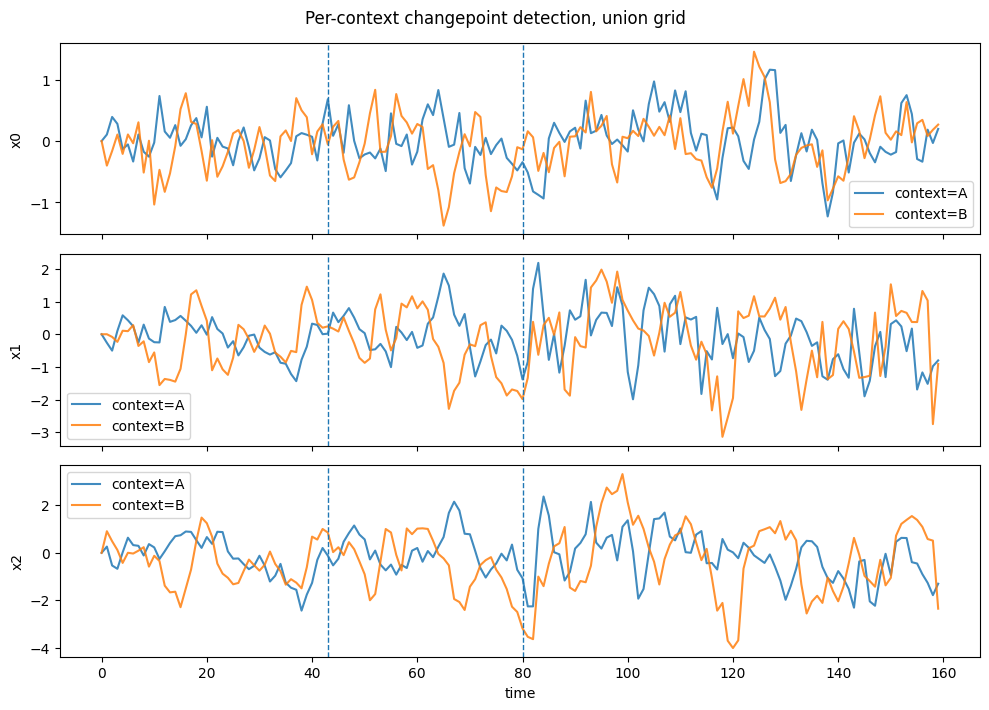

In [20]:
def print_changepoints(result):
    print("Changepoints used downstream:")
    print(result.changepoints)

    if result.changepoints_by_context is not None:
        print("\nChangepoints by context:")
        for context, changepoints in result.changepoints_by_context.items():
            print(f"  {context}: {changepoints}")


cc_per_context = CausalChange(
    data_mode=DataMode.TIME_CONTEXTS,
    graph_search=GraphSearch.GLOBE,
    score_type=ScoreType.LIN,
    context_mode=ContextMode.SKIP,
    context_col="context",
    tau_max=2,
    changepoint_mode=ChangepointMode.DETECT,
    changepoint_scope=ChangepointScope.PER_CONTEXT,
    pelt_penalty="auto",
)

cc_per_context.fit(X)

print_changepoints(cc_per_context.result_)

plot_changepoints(
    X,
    changepoints=cc_per_context.changepoints_,
    context_col="context",
    title="Per-context changepoint detection, union grid",
)

cc_per_context.result_.changepoint_diagnostics